In [1]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable

## Connect and get data

In [2]:
conn = sqlite3.connect('../data/checking-logs.sqlite')

commits = pd.io.sql.read_sql(
    """
    SELECT uid, timestamp
    FROM checker
    WHERE uid LIKE 'user_%'
    AND status = 'ready'
    """,
    conn,
    parse_dates=['timestamp']
)

conn.close()
commits.head()

,uid,timestamp
0,user_4,2020-04-17 05:19:02.744528
1,user_4,2020-04-17 05:22:45.549397
2,user_4,2020-04-17 05:34:24.422370
3,user_4,2020-04-17 05:43:27.773992
4,user_4,2020-04-17 05:46:32.275104


## Add weekday and hour columns

In [3]:
commits['weekday'] = commits['timestamp'].dt.day_name()
commits['hour'] = commits['timestamp'].dt.hour

# Count commits per user per weekday
by_user_weekday = commits.groupby(['uid', 'weekday']).size().unstack(fill_value=0)

# Count commits per user per hour
by_user_hour = commits.groupby(['uid', 'hour']).size().unstack(fill_value=0)

# Sort by total commits
by_user_weekday = by_user_weekday.loc[by_user_weekday.sum(axis=1).sort_values(ascending=False).index]
by_user_hour = by_user_hour.loc[by_user_hour.sum(axis=1).sort_values(ascending=False).index]

# Order weekdays properly
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
by_user_weekday = by_user_weekday.reindex(columns=[d for d in weekday_order if d in by_user_weekday.columns])

print(by_user_weekday.shape)
print(by_user_hour.shape)

(30, 7)
(30, 22)


## Plot heatmaps

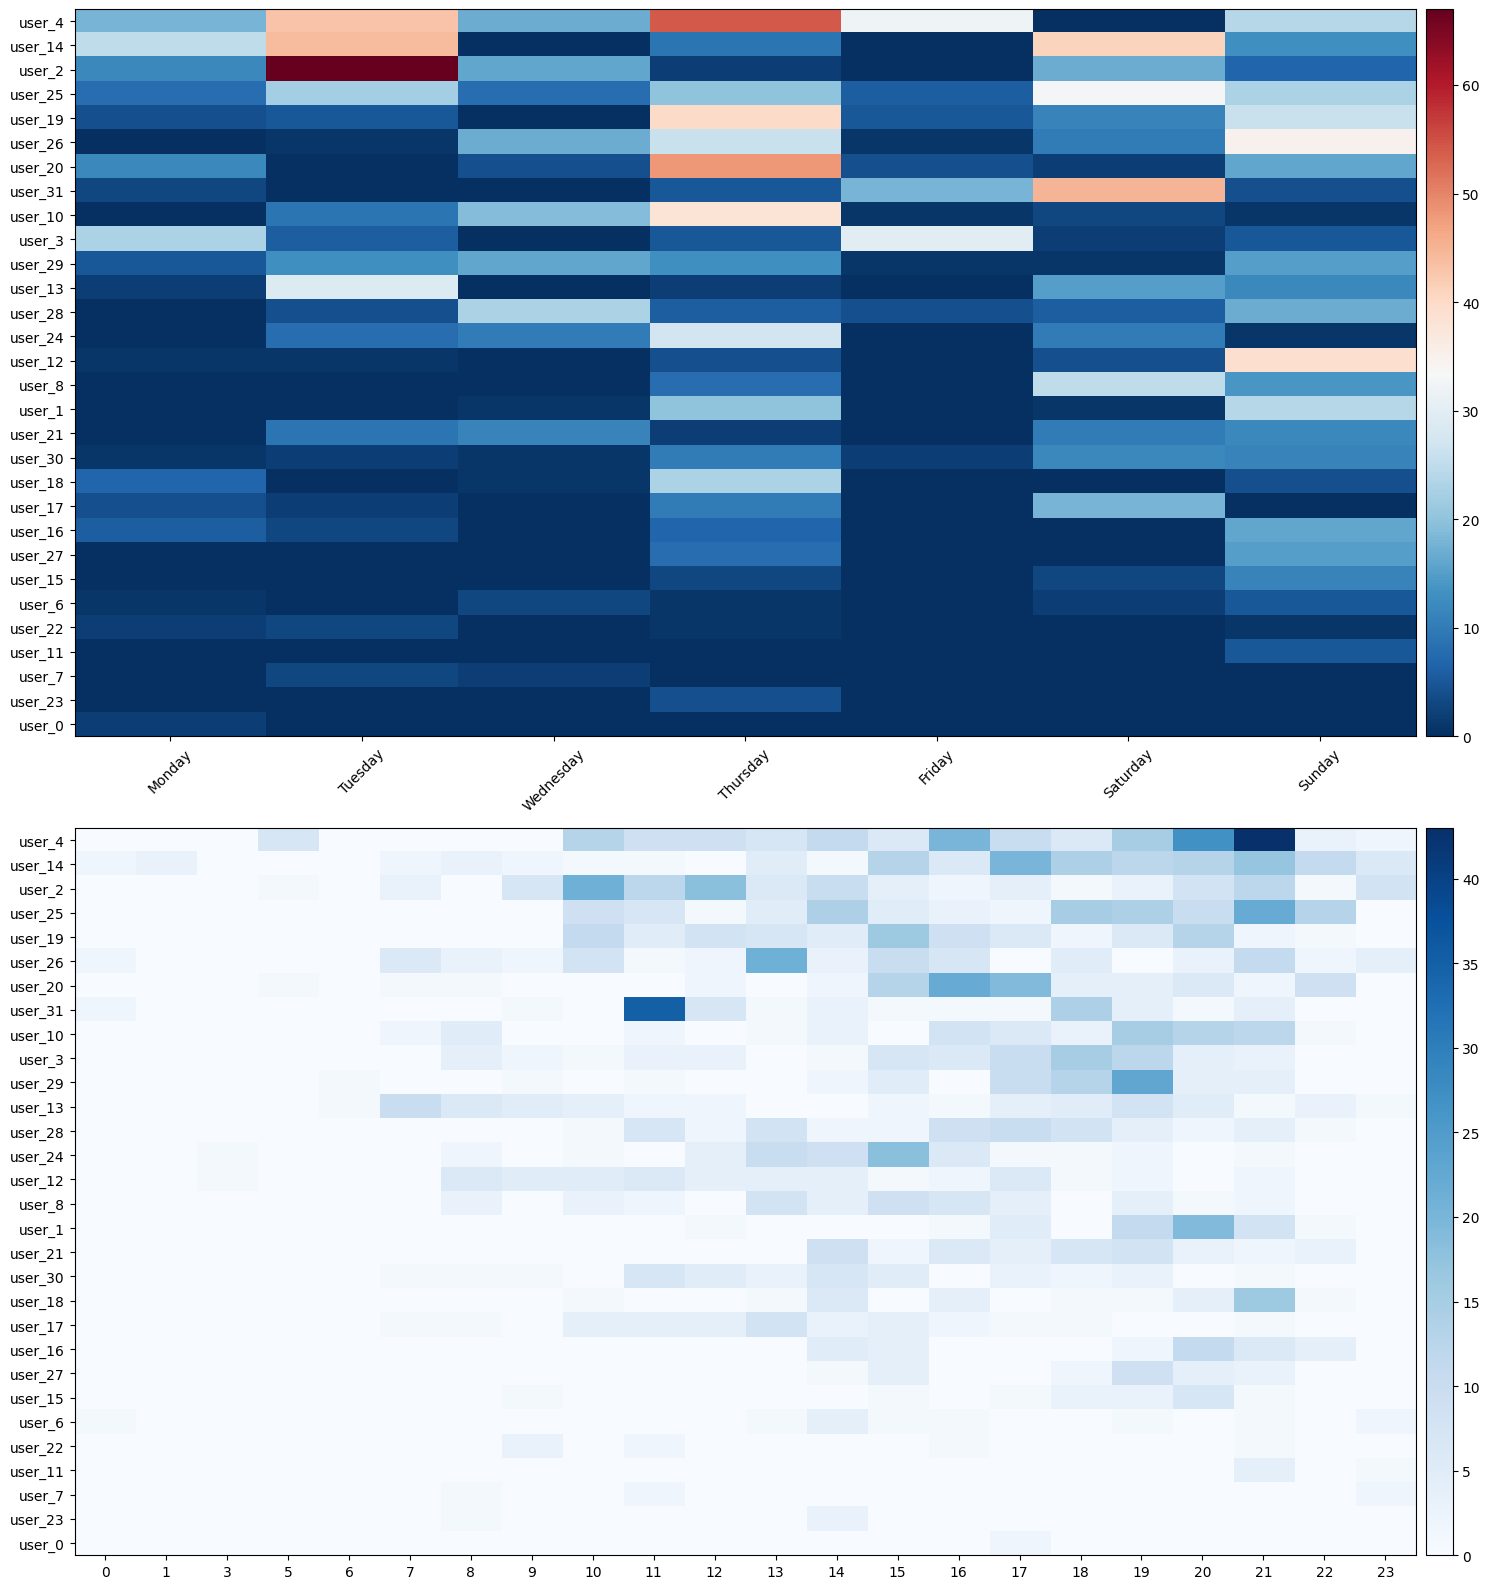

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 16))

# Heatmap 1: user vs weekday
im1 = axes[0].imshow(by_user_weekday.values, aspect='auto', cmap='RdBu_r')
axes[0].set_xticks(range(len(by_user_weekday.columns)))
axes[0].set_xticklabels(by_user_weekday.columns, rotation=45)
axes[0].set_yticks(range(len(by_user_weekday.index)))
axes[0].set_yticklabels(by_user_weekday.index)
div1 = make_axes_locatable(axes[0])
cax1 = div1.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im1, cax=cax1)

# Heatmap 2: user vs hour
im2 = axes[1].imshow(by_user_hour.values, aspect='auto', cmap='Blues')
axes[1].set_xticks(range(len(by_user_hour.columns)))
axes[1].set_xticklabels(by_user_hour.columns)
axes[1].set_yticks(range(len(by_user_hour.index)))
axes[1].set_yticklabels(by_user_hour.index)
div2 = make_axes_locatable(axes[1])
cax2 = div2.append_axes('right', size='2%', pad=0.1)
plt.colorbar(im2, cax=cax2)

plt.tight_layout()
plt.show()

## Answer questions

In [5]:
# Most commits on Tuesday
tuesday = by_user_weekday['Tuesday'] if 'Tuesday' in by_user_weekday.columns else None
if tuesday is not None:
    print('Most commits on Tuesday:', tuesday.idxmax())

# Most commits on Thursday
thursday = by_user_weekday['Thursday'] if 'Thursday' in by_user_weekday.columns else None
if thursday is not None:
    print('Most commits on Thursday:', thursday.idxmax())

# Least popular weekday
print('Least popular weekday:', by_user_weekday.sum().idxmin())

# User with most commits at a single hour
max_val = by_user_hour.values.max()
max_pos = (by_user_hour == max_val)
user_max = by_user_hour[max_pos.any(axis=1)].index[0]
hour_max = by_user_hour.columns[max_pos.any(axis=0)][0]
print(f'User with most commits at one hour: {user_max}, hour: {hour_max}')

Most commits on Tuesday: user_2
Most commits on Thursday: user_4
Least popular weekday: Friday
User with most commits at one hour: user_4, hour: 21


Which user has the most commits on Tuesday? The answer is user_*: user_2.

Which user has the most commits on Thursday? The answer is user_*: user_4.

On which weekday do users not like to make a lot of commits? The answer is: Friday.

Which user made the largest number of commits at which hour? The answer is user_*, hour: user_4, 21.